# 第0回：Environment & Dataset Foundation

第0回は、環境のテストです。これから扱う深層学習モデルはpytorchやgpuの利用前提(cpuでも動きますが処理能力の高いものでなければ、とても時間がかかります)なので、事前に動かせる環境かどうかをテストするコードをおいています。

# 1.環境チェック
以下のセルを "Shift +Enter"または上にある再生ボタンで順次実行していってください。エラーが出なければ環境の準備はokです。

## pytorch test
gpuで高速に演算を行うために必要なライブラリのテストです

In [2]:
# 実行環境のセルフチェック用
import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch: 2.11.0+cu130
CUDA available: True


## GPUの詳細情報の確認
「CUDA available: True」でcudaなど環境が整ったら、どのGPUが認識されているのか確認します。メモリ(VRAM)が小さい場合(８GB以下など)はバッチサイズを調整する必要があるかもしれません。

In [11]:
if torch.cuda.is_available():
    device_id = 0 # デフォルトのデバイス
    
    # GPU名の取得
    gpu_name = torch.cuda.get_device_name(device_id)
    
    # 計算能力（Capability）の取得: (major, minor) のタプルで返ります
    capability = torch.cuda.get_device_capability(device_id)
    
    # VRAM容量の取得（バイト単位で返るのでGBに変換）
    props = torch.cuda.get_device_properties(device_id)
    vram_gb = props.total_memory / (1024**3)

    print(f"GPU Name: {gpu_name}")
    print(f"Compute Capability: {capability[0]}.{capability[1]}")
    print(f"VRAM: {vram_gb:.2f} GB")
else:
    print("GPU is not detected. Using CPU mode.")

GPU Name: NVIDIA GeForce RTX 3090
Compute Capability: 8.6
VRAM: 23.56 GB


## グラフィックス（Matplotlib）の描画テスト
ノートブック上でグラフが正しく表示されるか、日本語やフォントでエラーが出ないかを確認。

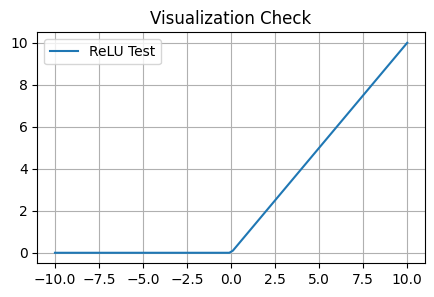

グラフが表示されていればOKです！


In [7]:
# 可視化ライブラリのチェック
import matplotlib.pyplot as plt
import numpy as np

%matplotlib inline 

x = np.linspace(-10, 10, 100)
y = np.maximum(0, x) # 簡易的なReLU

plt.figure(figsize=(5, 3))
plt.plot(x, y, label="ReLU Test")
plt.title("Visualization Check")
plt.legend()
plt.grid(True)
plt.show()

print("グラフが表示されていればOKです！")

# 2.このサンプル集の目的
「数式だけで終わらせず、PyTorchで実装して挙動を可視化する」これを念頭に、活性化関数のグラフや数式だけで終わらず、実際に動かしてみてどう違うのか、また、活性化関数を変えて試したいときにコピペできるようなリファレンスとして活用できることを目的として開発しています.

# 3.対象とするデータセットとモデルの例
しばらくはシンプルな活性化関数を紹介するため、直近でよく使う標準的なデータセットとモデルについて紹介します。
今後、複雑であったり得意な分野がある活性化関数について紹介する場合はそれに合わせて対象を変えていく予定です。

## mnistとは？
活性化関数のテストのため、シンプルで用意がかんたんなMNISTの手書き文字データセットの分類を対象に実験をしていく予定なので、このデータセットについて紹介します。

## mnist手書き文字データセットの中身
![mnist手書き文字](../sampleImages/000_mnist_relu.png "mnist手書き文字")

mnistの手書き文字データセットの中には、64*64サイズのグレースケール画像で手書き文字の ｛0~9｝の数字を書いた画像と対応する数字のデータがあります

## 分類モデル
### CNN（畳み込みニューラルネットワーク）とは？
分類モデルとは、入力されたデータ（今回は手書き数字の画像）が、あらかじめ決められたどのクラス（0〜9の数字）に属するかを予測する仕組みのことです。

中でもCNN（Convolutional Neural Network）は、画像の「形」を捉えるのが得意なモデルです。人間が「横棒があるから『7』かな？」と判断するように、CNNは画像の中から特徴的なパターンを見つけ出します。

このシリーズでは、以下のような構造のCNNを共通の「実験場」として使います。
 - 畳み込み層 (Convolutional Layer): 画像からエッジ（端）や模様などの特徴を抽出します。
 - プーリング層 (Pooling Layer): 特徴を凝縮し、少しのズレや変形に強いデータにします。
 - 全結合層 (Fully Connected Layer): 抽出された特徴を組み合わせて、最終的に「これは『5』だ！」と決定を下します。
   全結合層の中身については[ゼロから作る全結合層](https://tukumolog.com/nn-fc-layer-01-roadmap/)シリーズにてで詳しく、なぜ非線形関数が活性化関数として必要なのかを解説しています。
   
#### なぜ「活性化関数」に注目するのか？
[ゼロから作る全結合層](https://tukumolog.com/nn-fc-layer-01-roadmap/) にて詳しく解説していますが、活性化関数が必要な理由を端的に言うと以下のような理由があります。

CNNの計算の大部分は単純な「掛け算と足し算」の繰り返し（線形変換）に過ぎません。しかし、そのままではどれだけ層を深くしても、結局は一つの複雑な「足し算」にしかならず、複雑な形を捉えることができません。
そこで登場するのが活性化関数です。
活性化関数は、各層の計算結果に対して「非線形な変化（曲がり具合）」を加える役割を持っており、これが複雑な対象に対して効率的に推論する仕組みのコアとなっています。

### このシリーズの進め方
今後の検証では、モデルの形（層の数やフィルターの大きさ）は一切変えません。変えるのは「活性化関数」だけです。

「関数を一つ変えるだけで、AIの成長（学習曲線）がどう変化するのか？」

そのダイナミックな違いを、実際にコードを動かしながら体感していきましょう

# 次回は 最も有名なRelu関数です。
現代の深層学習において欠かせない存在となったReLU。そのシンプルな形状を改めて確認するとともに、実際にMNISTの手書き文字分類を通じて、学習効率や精度を検証していきます。全ての実験の「基準点（ベンチマーク）」となる第1回、ぜひご期待ください。

次回のファイル : __001_ReLU_Baseline.ipynb__ 

次回の記事   　: